<a href="https://colab.research.google.com/github/PauloFernandes26/AD2526/blob/main/AD2526_LabAssignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
# Setup, Version check and Common imports

# Python ≥ 3.7 is required
import sys
assert sys.version_info >= (3, 7)


# TensorFlow ≥ 2.8 is required
import tensorflow as tf
from packaging import version

assert version.parse(tf.__version__) >= version.parse("2.8.0")

# Common imports
import numpy as np
import os
import pandas as pd

from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

print('Python version: ', sys.version_info)
print('TF version: ', tf.__version__)
print('Keras version: ', keras.__version__)
print('GPU is', 'available' if tf.config.list_physical_devices('GPU') else 'NOT AVAILABLE')

Python version:  sys.version_info(major=3, minor=12, micro=13, releaselevel='final', serial=0)
TF version:  2.19.0
Keras version:  3.13.2
GPU is available


**Function to generate time series**

In [52]:
# This function generates multivariate time series
# It generates nr_series series, each one with n_steps values
# Each step has n_features. With multivariate time series (n_features > 1),
# a correlation between them can be specified (default value is 0.7)
# The amount of noise in the series must be specified.

# It returns a NumPy array of shape [nr_series, n_steps, n_features]

def generate_time_series(nr_series, n_steps, n_features, noise_factor, corr_strength=0.7):

    time = np.linspace(0, 1, n_steps)

    freq1, freq2, offset1, offset2 = np.random.rand(4, nr_series, 1)
    base = 0.5 * np.sin((time - offset1) * (freq1 * 10 + 10))
    base += 0.2 * np.sin((time - offset2) * (freq2 * 20 + 20))
    base += noise_factor * (np.random.rand(nr_series, n_steps) - 0.5)

    series = [base]

    for i in range(1, n_features):
        noise = noise_factor * (np.random.rand(nr_series, n_steps) - 0.5)
        correlated = corr_strength * base + (1 - corr_strength) * noise
        series.append(correlated)

    series = np.stack(series, axis=-1)
    return series.astype(np.float32)

In [53]:
# Function to visualize time series

def plot_multivariate_series(series, y=None, y_pred=None, x_label="t", y_label="x(t)"):

    series = np.asarray(series)

    if series.ndim == 1:
        series = series[:, np.newaxis]

    n_steps, n_features = series.shape
    plt.figure(figsize=(10, 4))

    colors = plt.cm.viridis(np.linspace(0, 1, n_features))

    for i in range(n_features):
        plt.plot(series[:, i], ".-", label=f"Feature {i+1}", color=colors[i])

        if y is not None:
            plt.plot(n_steps, y[i] if np.ndim(y) > 0 else y, "bx", markersize=10)
        if y_pred is not None:
            plt.plot(n_steps, y_pred[i] if np.ndim(y_pred) > 0 else y_pred, "ro")

    plt.grid(True)
    plt.xlabel(x_label, fontsize=16)
    plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, n_steps + 1, linewidth=1, color="gray")

    ymin = series.min() - 0.1
    ymax = series.max() + 0.1
    plt.axis([0, n_steps, ymin, ymax])

    plt.legend()
    plt.show()

**Multivariate TimeSeries with 3 Features**

**1. Datasets Creation**

Shape of S1: (10000, 51, 3)

Dataset 1 Shapes:
X_train: (7000, 50, 3) y_train: (7000, 3)
X_valid: (2000, 50, 3) y_valid: (2000, 3)
X_test: (1000, 50, 3) y_test: (1000, 3)


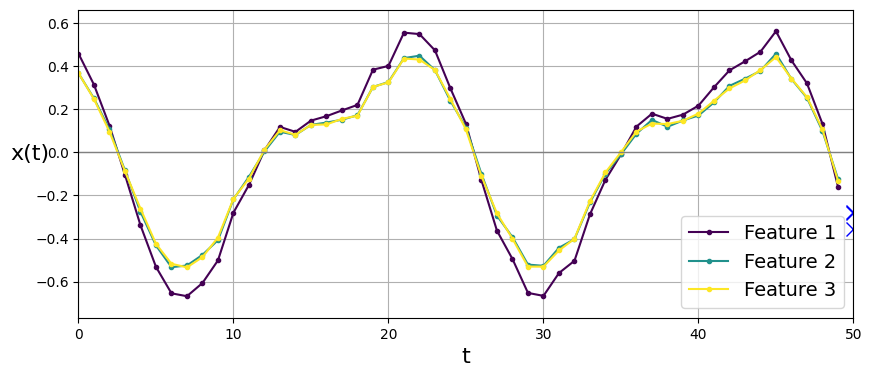

In [58]:
# Dataset 1

# Generate the datasets for training, validation and testing
# Each time series has 50 steps

np.random.seed(42)

# Parameters
n_steps = 50
n_features = 3
noise_factor = 0.1       # Mantido constante
correlation_1 = 0.8      # Alta correlação

# Generate dataset
S1 = generate_time_series(
    nr_series=10000,
    n_steps=n_steps + 1,
    n_features=n_features,
    noise_factor=noise_factor,
    corr_strength=correlation_1
)

print("Shape of S1:", S1.shape)

# Split into training, validation and test sets
X_train_1 = S1[:7000, :n_steps]
y_train_1 = S1[:7000, -1]

X_valid_1 = S1[7000:9000, :n_steps]
y_valid_1 = S1[7000:9000, -1]

X_test_1 = S1[9000:, :n_steps]
y_test_1 = S1[9000:, -1]

# Display shapes
print("\nDataset 1 Shapes:")
print("X_train:", X_train_1.shape, "y_train:", y_train_1.shape)
print("X_valid:", X_valid_1.shape, "y_valid:", y_valid_1.shape)
print("X_test:", X_test_1.shape, "y_test:", y_test_1.shape)

# Plot example
plot_multivariate_series(X_train_1[0], y_train_1[0])


In [72]:
# Baseline 1

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

baseline_model = keras.Sequential([
    layers.Input(shape=(50, 3)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(3)
])

baseline_model.summary()

baseline_model.compile(loss='mse', optimizer='adam')

history = baseline_model.fit(X_train_1, y_train_1, epochs=20,
                    validation_data=(X_valid_1, y_valid_1))



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,931 (19.26 KB)

 Trainable params: 4,931 (19.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0233 - val_loss: 0.0082
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0062 - val_loss: 0.0050
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0043 - val_loss: 0.0042
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0037 - val_loss: 0.0038
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0034 - val_loss: 0.0035
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0030 - val_loss: 0.0031
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0029 - val_loss: 0.0031
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0027 - val_loss: 0.0030
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0027 - val_loss: 0.0029
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [73]:
# MSE test error

baseline_model.evaluate(X_test_1, y_test_1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0027


0.002653093310073018

In [74]:
# RECURRENT ARCHITECTURE

keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)


Rnn_model = keras.models.Sequential([
    layers.Input(shape=(50, 3)),
        layers.LSTM(32),
        layers.Dense(16, activation='relu'),
        layers.Dense(3)
])

Rnn_model.summary()

Rnn_model.compile(loss='mse', optimizer='adam')

history = Rnn_model.fit(X_train_1, y_train_1, epochs=20,
                    validation_data=(X_valid_1, y_valid_1))

# Evalue MSE on test set

Rnn_model.evaluate(X_test_1, y_test_1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,187 (20.26 KB)

 Trainable params: 5,187 (20.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0254 - val_loss: 0.0051
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0040 - val_loss: 0.0029
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0031 - val_loss: 0.0028
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0029 - val_loss: 0.0027
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0027 - val_loss: 0.0025
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

0.0022223282139748335

Shape of S2: (10000, 51, 3)

Dataset 2 Shapes:
X_train: (7000, 50, 3) y_train: (7000, 3)
X_valid: (2000, 50, 3) y_valid: (2000, 3)
X_test: (1000, 50, 3) y_test: (1000, 3)


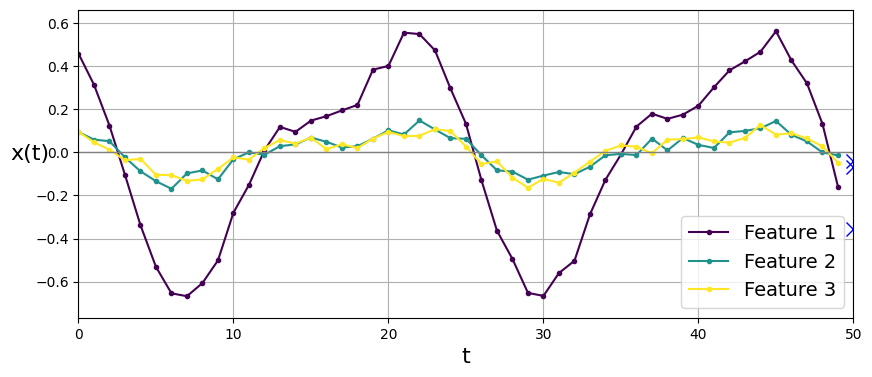

In [75]:
# Dataset 2
np.random.seed(42)

# Parameters
n_steps = 50
n_features = 3
noise_factor = 0.1       # Mantido constante
correlation_2 = 0.2      # Baixa correlação

# Generate dataset
S2 = generate_time_series(
    nr_series=10000,
    n_steps=n_steps + 1,
    n_features=n_features,
    noise_factor=noise_factor,
    corr_strength=correlation_2
)

print("Shape of S2:", S2.shape)

# Split into training, validation and test sets
X_train_2 = S2[:7000, :n_steps]
y_train_2 = S2[:7000, -1]

X_valid_2 = S2[7000:9000, :n_steps]
y_valid_2 = S2[7000:9000, -1]

X_test_2 = S2[9000:, :n_steps]
y_test_2 = S2[9000:, -1]

# Display shapes
print("\nDataset 2 Shapes:")
print("X_train:", X_train_2.shape, "y_train:", y_train_2.shape)
print("X_valid:", X_valid_2.shape, "y_valid:", y_valid_2.shape)
print("X_test:", X_test_2.shape, "y_test:", y_test_2.shape)

# Plot example
plot_multivariate_series(X_train_2[0], y_train_2[0])

In [76]:
#baselina dataset 2


keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

baseline_model2 = keras.Sequential([
    layers.Input(shape=(50, 3)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(3)
])

baseline_model2.summary()

baseline_model2.compile(loss='mse', optimizer='adam')

history = baseline_model2.fit(X_train_2, y_train_2, epochs=20,
                    validation_data=(X_valid_2, y_valid_2))




Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,931 (19.26 KB)

 Trainable params: 4,931 (19.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0151 - val_loss: 0.0053
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0042 - val_loss: 0.0035
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0030 - val_loss: 0.0028
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0023 - val_loss: 0.0023
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0021 - val_loss: 0.0022
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [77]:
# MSE test error

baseline_model2.evaluate(X_test_2, y_test_2)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0017


0.0017377154435962439

In [78]:
#recurrent dataset 2

keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)


Rnn_model2 = keras.models.Sequential([
    layers.Input(shape=(50, 3)),
        layers.LSTM(32),
        layers.Dense(16, activation='relu'),
        layers.Dense(3)
])

Rnn_model2.summary()

Rnn_model2.compile(loss='mse', optimizer='adam')

history = Rnn_model2.fit(X_train_2, y_train_2, epochs=20,
                    validation_data=(X_valid_2, y_valid_2))

# Evalue MSE on test set

Rnn_model2.evaluate(X_test_2, y_test_2)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,187 (20.26 KB)

 Trainable params: 5,187 (20.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0116 - val_loss: 0.0029
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0018 - val_loss: 0.0016
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/ste

0.0013837345177307725

In [84]:
import pandas as pd

# Criar tabela de resultados
results_table = pd.DataFrame({
    "Dataset": [
        "Dataset 1 (Corr = 0.8)",
        "Dataset 1 (Corr = 0.8)",
        "Dataset 2 (Corr = 0.2)",
        "Dataset 2 (Corr = 0.2)"
    ],
    "Architecture": [
        "Baseline",
        "Recurrent (LSTM)",
        "Baseline",
        "Recurrent (LSTM)"
    ],
    "Test MSE": [
        baseline_model,
        Rnn_model,
        baseline_model2,
        Rnn_model2
        ]
})

# Arredondar os valores para melhor leitura
results_table["Test MSE"] = results_table["Test MSE"].round(6)

# Mostrar a tabela
print("\nComparison of Architectures:")
print(results_table)




Comparison of Architectures:
                  Dataset      Architecture  \
0  Dataset 1 (Corr = 0.8)          Baseline   
1  Dataset 1 (Corr = 0.8)  Recurrent (LSTM)   
2  Dataset 2 (Corr = 0.2)          Baseline   
3  Dataset 2 (Corr = 0.2)  Recurrent (LSTM)   

                                   Test MSE  
0  <Sequential name=sequential, built=True>  
1  <Sequential name=sequential, built=True>  
2  <Sequential name=sequential, built=True>  
3  <Sequential name=sequential, built=True>  
